In [25]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
MODEL_NAME = "gemma-4-26b-a4b-it"

In [26]:
from langgraph.graph import StateGraph , START, END
from typing import  TypedDict , Annotated
import operator
from langgraph.prebuilt import ToolNode , tools_condition

In [27]:
from langchain.tools import tool
from langchain.messages import HumanMessage, AnyMessage, ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI

In [28]:
model = ChatGoogleGenerativeAI(
    model=MODEL_NAME
)

In [29]:
class AgentSchema(TypedDict):
    messages : Annotated[list[AnyMessage], operator.add]

In [30]:
@tool
def add(a:int , b:int)-> int:
    """"calculate the sum of these numbers"""
    return a+b

In [31]:
tools = [add]
model_with_tools = model.bind_tools(tools)

In [32]:
def llm_node(state: AgentSchema) -> dict:
    response = model_with_tools.invoke(state['messages'])
    return {
        'messages':[response]
    }

In [33]:
# BUILT-IN TOOL NODE
tool_node = ToolNode(tools)

In [34]:
# def tool_node(state:AgentSchema) ->dict:
#     result = []
#     last_message = state['messages'][-1]
#     for tool_call in last_message.tool_calls:
#         tool_result = add.invoke(tool_call['args'])

#         result.append(
#             ToolMessage(
#             content=str(tool_result),
#             tool_call_id = tool_call['id']
#             )
#         )
#     return {
#         'messages' : result
#     }

In [35]:
# def routing_decision(state: AgentSchema) :
#     last_message = state['messages'][-1]
#     if last_message.tool_calls:
#         return 'tool_node'
#     return END

In [36]:
graph = StateGraph(AgentSchema)

In [37]:
graph.add_node('llm_node',llm_node)
graph.add_node('tool_node',tool_node)

graph.add_edge(START, 'llm_node')

graph.add_conditional_edges(
    "llm_node",
    tools_condition,
    {
        "tools": "tool_node",
        "__end__": END
    }
)
graph.add_edge('tool_node','llm_node')

In [38]:
agent = graph.compile()

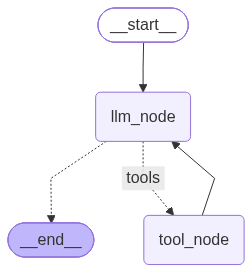

In [39]:
agent

In [40]:
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="What is 25 + 17?"
            )
        ]
    }
)

In [41]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 25 + 17?
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user is asking for the sum of 25 and 17. I should use the `add` tool to calculate this.'}]
Tool Calls:
  add (call_1213906)
 Call ID: call_1213906
  Args:
    b: 17
    a: 25
================================= Tool Message =================================
Name: add

42
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The tool returned 42. I should now provide the answer to the user.'}, {'type': 'text', 'text': '25 + 17 = 42'}]


In [42]:
result = agent.invoke({
    "messages": [
        HumanMessage(content="hi i am emre")
    ]
})

In [43]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

hi i am emre
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user said "hi i am emre".\nThe user is introducing themselves.\nAcknowledge the introduction and greet them back politely.\n\nPlan:\n1. Greet Emre.\n2. Ask how I can help him today.'}, {'type': 'text', 'text': "Hello Emre! It's nice to meet you. How can I help you today?"}]
